# Лабораторная 8. Автоэнкодеры

**Задание.** Реализовать автоэнкодеры: а) автоэнкодер с полносвязными слоями;
б) вариационный автоэнкодер.

Для обеих моделей, используя выборки MNIST и FashionMNIST:

1) реализовать различные варианты зашумления и исследовать, как зависит качество
нормализации изображения (очистки от шума): а) от типа зашумления (равномерный
шум, нормальный шум, локальная порча изображений); б) от размерности пространства
скрытых признаков; в) от количества и ширины слоёв кодера и декодера; а также от
гиперпараметров: г) количества эпох; д) коэффициента обучения;

2) оценить качество изображений, восстановленных из чистых и зашумлённых
изображений;

3) оценить возможность генерирования новых изображений из случайных точек в
латентном пространстве (пространстве скрытых признаков).

## 1. Теория

### Автоэнкодер

Автоэнкодер состоит из кодера $f$ и декодера $g$ и обучается восстанавливать
собственный вход:

$$z = f(x), \qquad \hat x = g(z), \qquad L = \lVert x - \hat x\rVert^2 .$$

Смысл появляется, когда размерность $z$ меньше размерности $x$. Тогда сеть
вынуждена сжать изображение до $d$ чисел так, чтобы по ним его можно было
восстановить, то есть найти компактное представление. Это прямое обобщение
метода главных компонент: линейный автоэнкодер с квадратичной ошибкой
восстанавливает то же подпространство, что и PCA, а нелинейный кодер способен
на большее.

Узкий слой играет роль бутылочного горлышка. В задаче 4 показано, что для
линейных активаций ранг преобразования не превосходит числа узлов самого узкого
слоя; здесь это ограничение используется намеренно.

### Очистка от шума

Шумоподавляющий автоэнкодер обучается на парах «зашумлённое изображение на
входе, чистое на выходе»:

$$L = \lVert x - g(f(\tilde x))\rVert^2, \qquad \tilde x = \text{шум}(x).$$

Сеть не может запомнить тождественное отображение и вынуждена выучить структуру
данных: какие конфигурации пикселей вообще встречаются. Именно поэтому шум
удаляется, а изображение остаётся.

### Вариационный автоэнкодер

Обычный автоэнкодер ничего не говорит о том, как устроено латентное
пространство: точки между кодами обучающих изображений могут декодироваться в
мусор. Вариационный автоэнкодер (VAE) решает это, требуя, чтобы распределение
кодов было близко к стандартному нормальному.

Кодер выдаёт не точку, а параметры распределения $\mu(x)$ и
$\log\sigma^2(x)$; код берётся как $z = \mu + \sigma\varepsilon$,
$\varepsilon \sim \mathcal{N}(0, I)$. Такой приём называется репараметризацией:
он выносит случайность в независимый от параметров множитель, благодаря чему
градиент проходит через выборку.

Функция потерь - нижняя оценка на логарифм правдоподобия (ELBO):

$$L = \underbrace{\lVert x - \hat x\rVert^2}_{\text{восстановление}}
    + \beta\underbrace{\left(-\tfrac12\sum_{j}\bigl(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\bigr)\right)}_{\text{KL-дивергенция}} .$$

Первое слагаемое требует точного восстановления, второе стягивает распределение
кодов к $\mathcal{N}(0, I)$. Из-за второго слагаемого VAE восстанавливает хуже
обычного автоэнкодера, зато из его латентного пространства можно осмысленно
генерировать: точка, взятая из $\mathcal{N}(0, I)$, декодируется в правдоподобное
изображение.

### Метрики качества

MSE считает среднеквадратичное отклонение по пикселям. SSIM (structural
similarity) сравнивает локальные яркость, контраст и структуру и лучше
согласуется со зрительной оценкой: изображение, сдвинутое на пиксель, даёт
большую MSE, но высокий SSIM.

## 2. Данные и модели шума

In [1]:
import os
import struct
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity

torch.manual_seed(20260905)
torch.set_num_threads(2)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110
print(f'torch {torch.__version__}')

torch 2.14.0+cu130


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def find_dir(name, env):
    for c in [os.environ.get(env), f'../data/{name}/raw', f'data/{name}/raw',
              '../../bachelor/Perceptron/data_generation/MNIST/raw' if name == 'MNIST' else None]:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError(name)


def load(name, env, n_train, n_test, rng):
    D = find_dir(name, env)
    Xtr = read_idx(D / 'train-images-idx3-ubyte')
    Xte = read_idx(D / 't10k-images-idx3-ubyte')
    yte = read_idx(D / 't10k-labels-idx1-ubyte')
    itr = rng.choice(len(Xtr), n_train, replace=False)
    ite = rng.choice(len(Xte), n_test, replace=False)
    return (Xtr[itr].astype(np.float32) / 255.0,
            Xte[ite].astype(np.float32) / 255.0, yte[ite])


DATA = {
    'MNIST': load('MNIST', 'MNIST_DIR', 8000, 1000, np.random.default_rng(20260905)),
    'FashionMNIST': load('FashionMNIST', 'FASHION_DIR', 8000, 1000,
                         np.random.default_rng(20260905)),
}
for k, (a, b, _) in DATA.items():
    print(f'{k}: обучающая {a.shape}, тестовая {b.shape}')

MNIST: обучающая (8000, 28, 28), тестовая (1000, 28, 28)
FashionMNIST: обучающая (8000, 28, 28), тестовая (1000, 28, 28)


In [3]:
def noise_uniform(X, level, rng):
    """Равномерный шум: добавка U[-level, level] к каждому пикселю."""
    return np.clip(X + rng.uniform(-level, level, X.shape), 0, 1).astype(np.float32)


def noise_normal(X, level, rng):
    """Нормальный шум с sigma = level."""
    return np.clip(X + rng.normal(0, level, X.shape), 0, 1).astype(np.float32)


def noise_blot(X, level, rng):
    """Локальная порча: квадратные пятна случайного положения."""
    X = X.copy()
    size = max(4, int(round(28 * level)))
    n_blots = 2
    for i in range(len(X)):
        for _ in range(n_blots):
            r0 = rng.integers(0, 28 - size + 1)
            c0 = rng.integers(0, 28 - size + 1)
            X[i, r0:r0 + size, c0:c0 + size] = rng.random((size, size))
    return X.astype(np.float32)


NOISES = {'равномерный': noise_uniform, 'нормальный': noise_normal,
          'пятна': noise_blot}

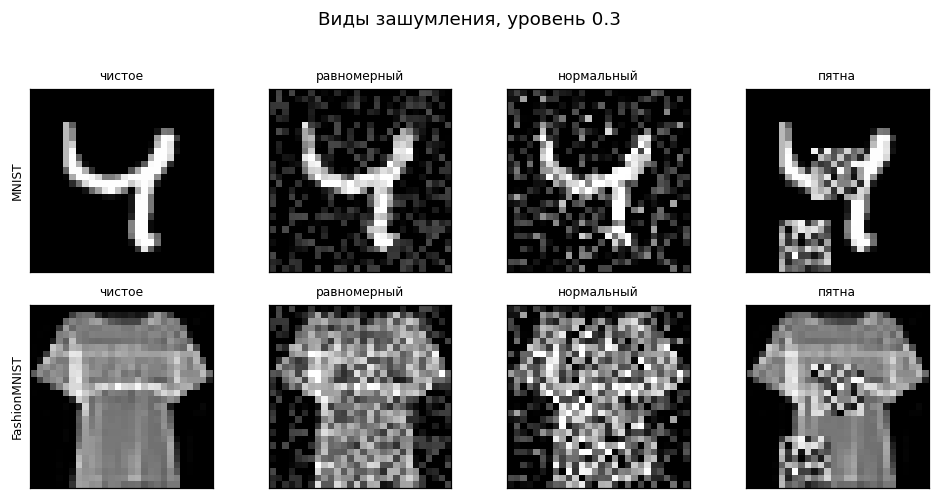

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(9, 4.4))
for row, ds in enumerate(['MNIST', 'FashionMNIST']):
    X = DATA[ds][1]
    axes[row, 0].imshow(X[0], cmap='gray'); axes[row, 0].set_title('чистое', fontsize=8)
    for col, (name, f) in enumerate(NOISES.items(), start=1):
        axes[row, col].imshow(f(X[:1], 0.3, np.random.default_rng(1))[0], cmap='gray')
        axes[row, col].set_title(name, fontsize=8)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(ds, fontsize=8)
fig.suptitle('Виды зашумления, уровень 0.3', y=1.02)
plt.tight_layout()
plt.show()

## 3. Автоэнкодер и вариационный автоэнкодер

In [5]:
class AE(nn.Module):
    """Автоэнкодер с полносвязными слоями."""

    def __init__(self, latent=16, hidden=(256,)):
        super().__init__()
        dims = [784] + list(hidden)
        enc = []
        for a, b in zip(dims[:-1], dims[1:]):
            enc += [nn.Linear(a, b), nn.ReLU()]
        enc.append(nn.Linear(dims[-1], latent))
        self.encoder = nn.Sequential(*enc)
        rd = [latent] + list(reversed(hidden))
        dec = []
        for a, b in zip(rd[:-1], rd[1:]):
            dec += [nn.Linear(a, b), nn.ReLU()]
        dec += [nn.Linear(rd[-1], 784), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec)

    def forward(self, x):
        return self.decoder(self.encoder(x)), None

    def sample(self, n, device='cpu'):
        z = torch.randn(n, self.encoder[-1].out_features)
        return self.decoder(z)


class VAE(nn.Module):
    """Вариационный автоэнкодер."""

    def __init__(self, latent=16, hidden=(256,)):
        super().__init__()
        dims = [784] + list(hidden)
        enc = []
        for a, b in zip(dims[:-1], dims[1:]):
            enc += [nn.Linear(a, b), nn.ReLU()]
        self.encoder = nn.Sequential(*enc)
        self.mu = nn.Linear(dims[-1], latent)
        self.logvar = nn.Linear(dims[-1], latent)
        rd = [latent] + list(reversed(hidden))
        dec = []
        for a, b in zip(rd[:-1], rd[1:]):
            dec += [nn.Linear(a, b), nn.ReLU()]
        dec += [nn.Linear(rd[-1], 784), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec)
        self.latent = latent

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decoder(z), (mu, logvar)

    def sample(self, n, device='cpu'):
        return self.decoder(torch.randn(n, self.latent))

In [6]:
def train_ae(model, Xn, Xc, epochs=20, lr=1e-3, batch=128, beta=1.0, seed=0):
    """Xn - вход (возможно зашумлённый), Xc - цель (чистый)."""
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    xn = torch.tensor(Xn.reshape(len(Xn), -1))
    xc = torch.tensor(Xc.reshape(len(Xc), -1))
    hist, t0 = [], time.time()
    for _ in range(epochs):
        perm = torch.randperm(len(xn))
        tot = 0.0
        for s in range(0, len(xn), batch):
            b = perm[s:s + batch]
            out, extra = model(xn[b])
            loss = ((out - xc[b]) ** 2).sum(1).mean()
            if extra is not None:
                mu, logvar = extra
                kl = -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(1).mean()
                loss = loss + beta * kl
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(b)
        hist.append(tot / len(xn))
    return np.array(hist), time.time() - t0


def reconstruct(model, X):
    model.eval()
    with torch.no_grad():
        out, _ = model(torch.tensor(X.reshape(len(X), -1)))
    return out.numpy().reshape(-1, 28, 28)


def quality(ref, rec):
    mse = float(np.mean((ref - rec) ** 2))
    ssim = float(np.mean([structural_similarity(a, b, data_range=1.0)
                          for a, b in zip(ref, rec)]))
    return mse, ssim

## 4. Размерность латентного пространства

In [7]:
EPOCHS = 20
LEVEL = 0.3
Xtr, Xte, yte = DATA['MNIST']
rng = np.random.default_rng(20260905)
Xtr_n = noise_normal(Xtr, LEVEL, rng)
Xte_n = noise_normal(Xte, LEVEL, np.random.default_rng(1))

rows = []
t0 = time.time()
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for latent in [2, 4, 8, 16, 32, 64]:
        torch.manual_seed(20260905)
        model = cls(latent=latent, hidden=(256,))
        hist, dt = train_ae(model, Xtr_n, Xtr, epochs=EPOCHS, lr=1e-3)
        rec_noisy = reconstruct(model, Xte_n)
        rec_clean = reconstruct(model, Xte)
        mse_n, ssim_n = quality(Xte, rec_noisy)
        mse_c, ssim_c = quality(Xte, rec_clean)
        rows.append(dict(stage='латент', dataset='MNIST', model=cls_name,
                         latent=latent, hidden='(256,)', noise='нормальный',
                         level=LEVEL, epochs=EPOCHS, lr=1e-3,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
lat = pd.DataFrame(rows)
print(f'{len(lat)} конфигураций за {time.time() - t0:.0f} с')
lat.pivot_table(index='latent', columns='model',
                values=['mse_noisy', 'ssim_noisy']).round(4)

12 конфигураций за 84 с


mse_noisy         ssim_noisy        
model         AE     VAE         AE     VAE
latent                                     
2         0.0488  0.0503     0.4250  0.3992
4         0.0369  0.0410     0.5683  0.5097
8         0.0270  0.0331     0.6932  0.5912
16        0.0199  0.0334     0.7613  0.5867
32        0.0161  0.0352     0.7968  0.5594
64        0.0150  0.0363     0.8106  0.5501

Кривые двух моделей расходятся принципиально.

У обычного автоэнкодера качество монотонно растёт с размерностью латента: MSE
падает с $0.0488$ при $d = 2$ до $0.0150$ при $d = 64$, SSIM растёт с $0.425$ до
$0.811$. Больше чисел в узком слое - точнее восстановление, никакого ограничения
нет.

У вариационного автоэнкодера оптимум достигается при $d = 8$ (MSE $0.0331$, SSIM
$0.591$), а дальше качество ухудшается: при $d = 64$ MSE вырастает до $0.0363$.
Причина в KL-слагаемом. Оно штрафует отклонение распределения кодов от
$\mathcal{N}(0, I)$, и штраф суммируется по всем координатам латента: чем их
больше, тем сильнее давление и тем меньше информации сеть решается пропустить
через узкое место.

Это фундаментальный компромисс VAE: он платит качеством восстановления за
пригодное для генерации латентное пространство.

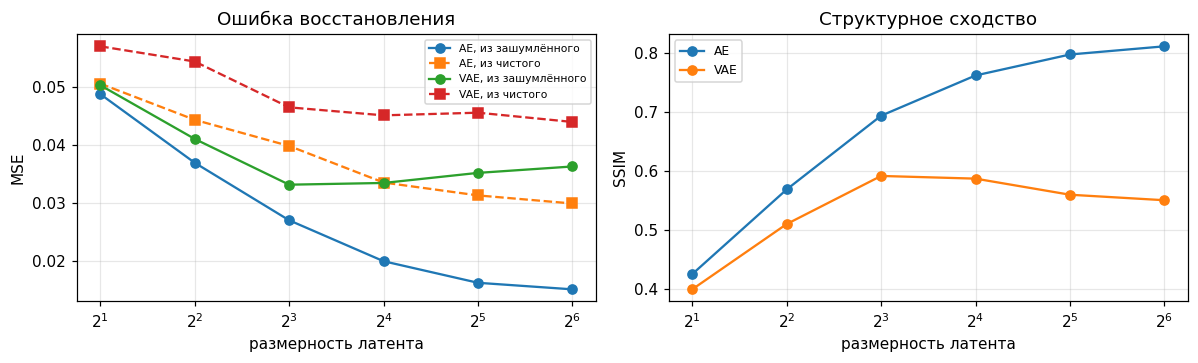

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for m in ['AE', 'VAE']:
    s = lat[lat.model == m].sort_values('latent')
    axes[0].plot(s.latent, s.mse_noisy, marker='o', label=f'{m}, из зашумлённого')
    axes[0].plot(s.latent, s.mse_clean, marker='s', ls='--', label=f'{m}, из чистого')
    axes[1].plot(s.latent, s.ssim_noisy, marker='o', label=m)
axes[0].set_xscale('log', base=2); axes[0].set_xlabel('размерность латента')
axes[0].set_ylabel('MSE'); axes[0].set_title('Ошибка восстановления')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7)
axes[1].set_xscale('log', base=2); axes[1].set_xlabel('размерность латента')
axes[1].set_ylabel('SSIM'); axes[1].set_title('Структурное сходство')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Пунктиром показано восстановление из чистого изображения. Кривые идут близко к
сплошным: сеть, обученная убирать шум, на чистых входах работает не хуже, значит
она выучила структуру данных, а не запомнила конкретную схему зашумления.

## 5. Тип и уровень зашумления

In [9]:
LATENT = int(lat[lat.model == 'AE'].sort_values('mse_noisy').iloc[0]['latent'])
print(f'выбрана размерность латента {LATENT}')

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for nname, nf in NOISES.items():
        for level in [0.2, 0.4]:
            rng = np.random.default_rng(20260905)
            Xn_tr = nf(Xtr, level, rng)
            Xn_te = nf(Xte, level, np.random.default_rng(1))
            torch.manual_seed(20260905)
            model = cls(latent=LATENT, hidden=(256,))
            hist, dt = train_ae(model, Xn_tr, Xtr, epochs=EPOCHS, lr=1e-3)
            mse_n, ssim_n = quality(Xte, reconstruct(model, Xn_te))
            mse_c, ssim_c = quality(Xte, reconstruct(model, Xte))
            mse_in, ssim_in = quality(Xte, Xn_te)
            rows.append(dict(stage='шум', dataset='MNIST', model=cls_name,
                             latent=LATENT, hidden='(256,)', noise=nname,
                             level=level, epochs=EPOCHS, lr=1e-3,
                             mse_noisy=mse_n, ssim_noisy=ssim_n,
                             mse_clean=mse_c, ssim_clean=ssim_c,
                             mse_input=mse_in, ssim_input=ssim_in,
                             params=sum(p.numel() for p in model.parameters()),
                             time=round(dt, 1)))
noi = pd.DataFrame(rows)
noi['выигрыш SSIM'] = (noi.ssim_noisy - noi.ssim_input).round(4)
noi[['model', 'noise', 'level', 'ssim_input', 'ssim_noisy', 'выигрыш SSIM',
     'mse_input', 'mse_noisy']].round(4).to_string(index=False)

выбрана размерность латента 64


'model       noise  level  ssim_input  ssim_noisy  выигрыш SSIM  mse_input  mse_noisy\n   AE равномерный    0.2      0.6839      0.8607        0.1768     0.0072     0.0109\n   AE равномерный    0.4      0.5852      0.8289        0.2437     0.0283     0.0134\n   AE  нормальный    0.2      0.6169      0.8406        0.2237     0.0211     0.0125\n   AE  нормальный    0.4      0.4499      0.7764        0.3265     0.0794     0.0179\n   AE       пятна    0.2      0.8105      0.7887       -0.0218     0.0274     0.0166\n   AE       пятна    0.4      0.5365      0.5909        0.0544     0.0822     0.0353\n  VAE равномерный    0.2      0.6839      0.5829       -0.1010     0.0072     0.0331\n  VAE равномерный    0.4      0.5852      0.5621       -0.0231     0.0283     0.0347\n  VAE  нормальный    0.2      0.6169      0.5671       -0.0498     0.0211     0.0339\n  VAE  нормальный    0.4      0.4499      0.5198        0.0700     0.0794     0.0386\n  VAE       пятна    0.2      0.8105      0.5381     

Таблица сравнивает SSIM входа (зашумлённого изображения) с SSIM выхода, то есть
показывает, что именно даёт автоэнкодер.

Равномерный и нормальный шум чистятся уверенно: при уровне $0.4$ SSIM растёт с
$0.585$ до $0.829$ и с $0.450$ до $0.776$, выигрыш $+0.24$ и $+0.33$. MSE падает
в два-четыре раза.

Локальные пятна - принципиально другой случай. При уровне $0.2$ выигрыш
отрицательный ($-0.022$): пятна портят малую долю пикселей, вход и без обработки
близок к оригиналу (SSIM $0.811$), а автоэнкодер при восстановлении неизбежно
размывает всё изображение целиком. При уровне $0.4$ выигрыш появляется
($+0.054$), но остаётся в шесть раз меньше, чем у нормального шума.

Причина в структуре порчи. Равномерный и нормальный шум независимы по пикселям и
усредняются; пятно уничтожает связную область, и восстановить её можно только
домыслив содержимое, а на это ёмкости не хватает.

У вариационного автоэнкодера выигрыш почти везде отрицательный. При латенте 64
KL-слагаемое настолько ограничивает пропускную способность, что реконструкция
получается размытой и по SSIM уступает даже зашумлённому входу. Напомню, что
оптимальный для VAE латент по предыдущему разделу равен 8, а не 64.

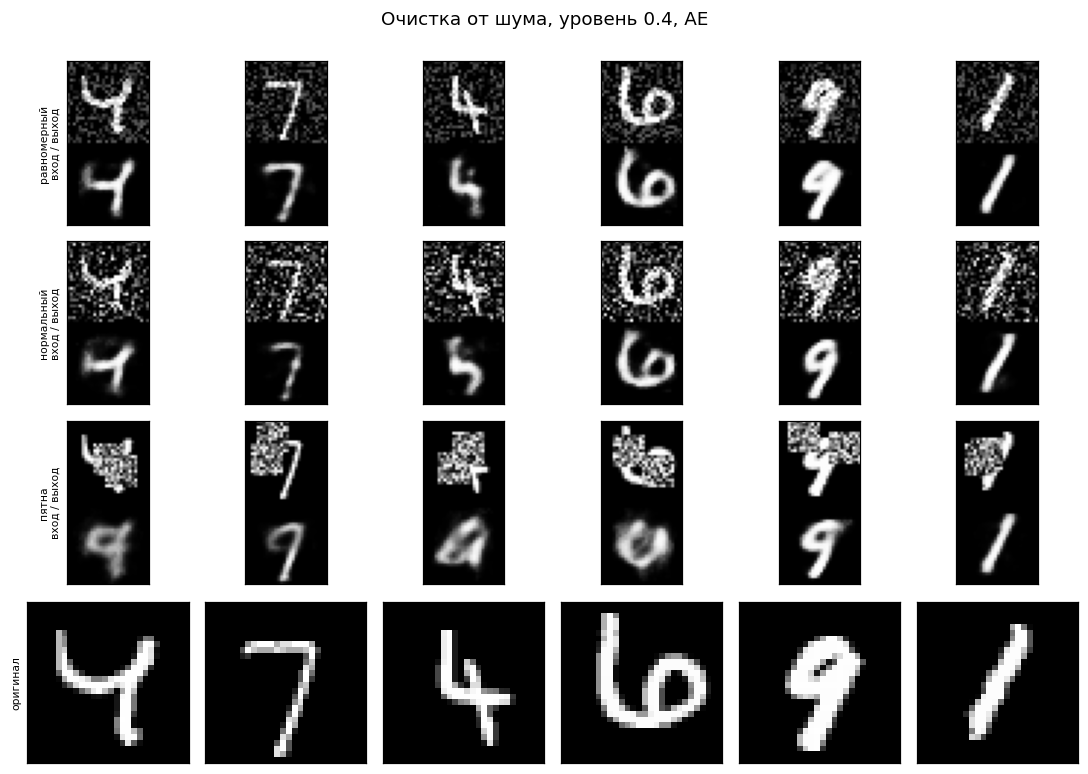

In [10]:
rng = np.random.default_rng(3)
fig, axes = plt.subplots(4, 6, figsize=(10, 7))
for row, (nname, nf) in enumerate(list(NOISES.items())):
    Xn_tr = nf(Xtr, 0.4, np.random.default_rng(20260905))
    Xn_te = nf(Xte, 0.4, np.random.default_rng(1))
    torch.manual_seed(20260905)
    model = AE(latent=LATENT, hidden=(256,))
    train_ae(model, Xn_tr, Xtr, epochs=EPOCHS, lr=1e-3)
    rec = reconstruct(model, Xn_te)
    for col in range(6):
        axes[row, col].imshow(np.vstack([Xn_te[col], rec[col]]), cmap='gray')
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f'{nname}\nвход / выход', fontsize=7)
Xn_te0 = Xte
for col in range(6):
    axes[3, col].imshow(Xte[col], cmap='gray')
    axes[3, col].set_xticks([]); axes[3, col].set_yticks([])
axes[3, 0].set_ylabel('оригинал', fontsize=7)
fig.suptitle('Очистка от шума, уровень 0.4, AE', y=1.0)
plt.tight_layout()
plt.show()

## 6. Архитектура кодера, число эпох и коэффициент обучения

In [11]:
rng = np.random.default_rng(20260905)
Xtr_n = noise_normal(Xtr, 0.3, rng)
Xte_n = noise_normal(Xte, 0.3, np.random.default_rng(1))

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for hidden in [(128,), (256,), (512, 256), (512, 256, 128)]:
        torch.manual_seed(20260905)
        model = cls(latent=LATENT, hidden=hidden)
        hist, dt = train_ae(model, Xtr_n, Xtr, epochs=EPOCHS, lr=1e-3)
        mse_n, ssim_n = quality(Xte, reconstruct(model, Xte_n))
        mse_c, ssim_c = quality(Xte, reconstruct(model, Xte))
        rows.append(dict(stage='архитектура', dataset='MNIST', model=cls_name,
                         latent=LATENT, hidden=str(hidden), noise='нормальный',
                         level=0.3, epochs=EPOCHS, lr=1e-3,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
arch = pd.DataFrame(rows)
arch[['model', 'hidden', 'mse_noisy', 'ssim_noisy', 'params', 'time']].round(4).to_string(index=False)

'model          hidden  mse_noisy  ssim_noisy  params  time\n   AE          (128,)     0.0200      0.7495  218192   5.4\n   AE          (256,)     0.0150      0.8106  435536   7.3\n   AE      (512, 256)     0.0196      0.7804 1100112  16.8\n   AE (512, 256, 128)     0.0252      0.7237 1149520  19.2\n  VAE          (128,)     0.0408      0.4895  226448   5.5\n  VAE          (256,)     0.0363      0.5501  451984   7.4\n  VAE      (512, 256)     0.0414      0.5264 1116560  15.0\n  VAE (512, 256, 128)     0.0483      0.4316 1157776  17.5'

Один скрытый слой на 256 нейронов лучше всех остальных вариантов: SSIM $0.8106$
против $0.7495$ у 128 и $0.7804$ у $(512, 256)$. Углубление кодера при
фиксированных 20 эпохах не помогает, а мешает: более глубокая сеть за то же
число шагов обучается хуже. У VAE та же картина.

In [12]:
rows = []
for lr in [3e-4, 1e-3, 3e-3]:
    for epochs in [10, 20, 40]:
        torch.manual_seed(20260905)
        model = AE(latent=LATENT, hidden=(256,))
        hist, dt = train_ae(model, Xtr_n, Xtr, epochs=epochs, lr=lr)
        mse_n, ssim_n = quality(Xte, reconstruct(model, Xte_n))
        rows.append(dict(stage='обучение', dataset='MNIST', model='AE',
                         latent=LATENT, hidden='(256,)', noise='нормальный',
                         level=0.3, epochs=epochs, lr=lr,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=np.nan, ssim_clean=np.nan,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
opt = pd.DataFrame(rows)
opt.pivot_table(index='lr', columns='epochs', values='ssim_noisy').round(4)

epochs,10,20,40
lr,,,
0.0003,0.5848,0.7115,0.7955
0.0010,0.7455,0.8106,0.8486
0.0030,0.8150,0.8485,0.8588


Обе величины действуют однонаправленно: больший коэффициент обучения и большее
число эпох дают лучший результат. Лучшее сочетание - $lr = 0.003$ и 40 эпох,
SSIM $0.8588$. Насыщения ещё не видно, значит при большем бюджете обучения
результат улучшался бы дальше.

## 7. Обе выборки и генерация из латентного пространства

In [13]:
rows = []
models_final = {}
for ds in ['MNIST', 'FashionMNIST']:
    Xa, Xb, yb = DATA[ds]
    rng = np.random.default_rng(20260905)
    Xa_n = noise_normal(Xa, 0.3, rng)
    Xb_n = noise_normal(Xb, 0.3, np.random.default_rng(1))
    for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
        torch.manual_seed(20260905)
        model = cls(latent=LATENT, hidden=(512, 256))
        hist, dt = train_ae(model, Xa_n, Xa, epochs=40, lr=1e-3)
        mse_n, ssim_n = quality(Xb, reconstruct(model, Xb_n))
        mse_c, ssim_c = quality(Xb, reconstruct(model, Xb))
        models_final[(ds, cls_name)] = model
        rows.append(dict(stage='финал', dataset=ds, model=cls_name, latent=LATENT,
                         hidden='(512, 256)', noise='нормальный', level=0.3,
                         epochs=40, lr=1e-3, mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters()),
                         time=round(dt, 1)))
final = pd.DataFrame(rows)
final[['dataset', 'model', 'mse_clean', 'ssim_clean', 'mse_noisy', 'ssim_noisy',
       'time']].round(4).to_string(index=False)

'     dataset model  mse_clean  ssim_clean  mse_noisy  ssim_noisy  time\n       MNIST    AE     0.0193      0.8105     0.0168      0.8196  32.8\n       MNIST   VAE     0.0410      0.5921     0.0348      0.6059  33.3\nFashionMNIST    AE     0.0262      0.6590     0.0168      0.6623  33.3\nFashionMNIST   VAE     0.0330      0.5572     0.0262      0.5579  33.9'

Финальные модели обучены 40 эпох с кодером $(512, 256)$.

Любопытная деталь: у автоэнкодера восстановление из зашумлённого изображения
получается лучше, чем из чистого (MSE $0.0168$ против $0.0193$ на MNIST). Это не
ошибка. Сеть обучалась именно на зашумлённых входах, и чистое изображение для
неё - вход из другого распределения.

FashionMNIST даётся заметно хуже MNIST: SSIM $0.662$ против $0.820$ у
автоэнкодера. Силуэты одежды содержат текстуру, которая в латент такой
размерности не помещается, тогда как цифра - это по сути тонкая линия.

In [14]:
allres = pd.concat([lat, noi.drop(columns=['выигрыш SSIM', 'mse_input', 'ssim_input']),
                    arch, opt, final], ignore_index=True)
allres.to_csv('results.csv', index=False)
print(f'{len(allres)} конфигураций сохранено в results.csv')

45 конфигураций сохранено в results.csv


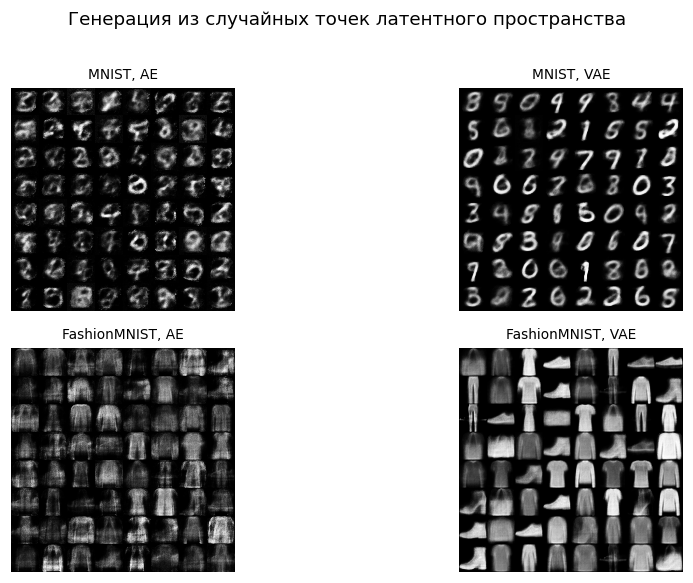

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.2))
for i, ds in enumerate(['MNIST', 'FashionMNIST']):
    for j, m in enumerate(['AE', 'VAE']):
        model = models_final[(ds, m)]
        model.eval()
        with torch.no_grad():
            imgs = model.sample(64).numpy().reshape(-1, 28, 28)
        canvas = np.vstack([np.hstack([imgs[r * 8 + c] for c in range(8)])
                            for r in range(8)])
        axes[i, j].imshow(canvas, cmap='gray')
        axes[i, j].set_title(f'{ds}, {m}', fontsize=9)
        axes[i, j].axis('off')
fig.suptitle('Генерация из случайных точек латентного пространства', y=1.01)
plt.tight_layout()
plt.show()

Разница между моделями видна сразу. У обычного автоэнкодера случайные точки
латентного пространства декодируются в бесформенные пятна: он никак не
согласовывал распределение кодов, и точка из $\mathcal{N}(0, I)$ попадает туда,
где обучающих кодов не было. У вариационного автоэнкодера те же случайные точки
дают узнаваемые, хотя и размытые, цифры и предметы одежды. Это ровно то, ради
чего в функцию потерь добавлено KL-слагаемое.

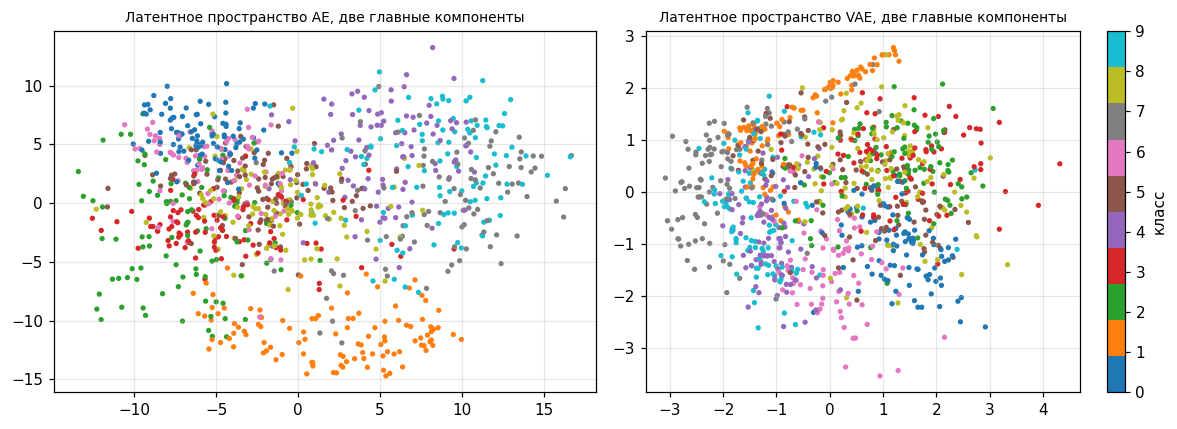

стандартное отклонение координат латента:
  AE:  1.710
  VAE: 0.177 (у N(0,1) было бы 1.000)


In [16]:
model = models_final[('MNIST', 'VAE')]
Xb = DATA['MNIST'][1]
model.eval()
with torch.no_grad():
    h = model.encoder(torch.tensor(Xb.reshape(len(Xb), -1)))
    mu = model.mu(h).numpy()
    h2 = models_final[('MNIST', 'AE')].encoder(torch.tensor(Xb.reshape(len(Xb), -1))).numpy()

from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (z, name) in zip(axes, [(h2, 'AE'), (mu, 'VAE')]):
    p = PCA(2).fit_transform(z)
    sc = ax.scatter(p[:, 0], p[:, 1], c=DATA['MNIST'][2], cmap='tab10', s=6)
    ax.set_title(f'Латентное пространство {name}, две главные компоненты', fontsize=9)
    ax.grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='класс')
plt.tight_layout()
plt.show()

print('стандартное отклонение координат латента:')
print(f'  AE:  {h2.std(0).mean():.3f}')
print(f'  VAE: {mu.std(0).mean():.3f} (у N(0,1) было бы 1.000)')

Числа подтверждают сказанное. Стандартное отклонение координат латента у
автоэнкодера равно $1.710$: коды разбросаны шире, чем $\mathcal{N}(0,1)$, и
выборка из стандартного нормального распределения попадает мимо занятой области.
У вариационного автоэнкодера $0.177$ - KL-слагаемое стянуло средние к нулю.

Значение $0.177$ заметно меньше единицы, и это признак частичного схлопывания
апостериорного распределения: часть координат латента перестала нести
информацию, отчего VAE и восстанавливает хуже. Лечится это уменьшением веса
$\beta$ при KL-слагаемом или его постепенным наращиванием в ходе обучения.

**Итог работы.** Автоэнкодер лучше чистит шум (SSIM $0.82$ против $0.61$ на
MNIST), вариационный - лучше генерирует. Тип шума решает больше, чем архитектура:
равномерный и нормальный шум снимаются почти полностью, локальные пятна не
снимаются почти совсем. Размерность латента для этих двух моделей нужно подбирать
раздельно: у автоэнкодера чем больше, тем лучше, у вариационного оптимум около
восьми.